# Phase 1: Setting the Environment and Dataset Structure

In [1]:
# Setting the directories

import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

RANDOM_SEED = 42
np.random.seed(RANDOM_SEED)

# Resolving project root
_cwd = os.path.abspath(os.getcwd())
BASE_DIR = os.path.dirname(_cwd) if os.path.basename(_cwd) == 'notebooks' else _cwd

PROCESSED_DIR = os.path.join(BASE_DIR, 'data', 'processed')
PLOTS_DIR     = os.path.join(BASE_DIR, 'outputs', 'plots')
MODELS_DIR    = os.path.join(BASE_DIR, 'outputs', 'models')
METRICS_DIR   = os.path.join(BASE_DIR, 'outputs', 'metrics')
PCA_COMP_DIR  = os.path.join(BASE_DIR, 'outputs', 'pca_components')
REPORTS_DIR   = os.path.join(BASE_DIR, 'reports')

# Creating folder hierarchy
for path in [PROCESSED_DIR, PLOTS_DIR, MODELS_DIR, METRICS_DIR, PCA_COMP_DIR, REPORTS_DIR]:
    os.makedirs(path, exist_ok=True)

In [2]:
# Loading dataset metadata

CDR_TO_LABEL = {
    0.0: 'Non-Demented',
    0.5: 'Very Mild Demented',
    1.0: 'Mild Demented',
    2.0: 'Moderate Demented'
}

LABEL_ORDER = ['Non-Demented', 'Very Mild Demented', 'Mild Demented', 'Moderate Demented']

mapping_path = os.path.join(PROCESSED_DIR, 'mapping.csv')
df = pd.read_csv(mapping_path)
df = df.rename(columns={'file_path': 'image_path', 'label': 'dementia_stage_label'})

print(f'Total samples  : {len(df)}')
print(f'Unique subjects: {df["subject_id"].nunique()}')
print()
print(df['dementia_stage_label'].value_counts().reindex(LABEL_ORDER))

Total samples  : 442
Unique subjects: 436

dementia_stage_label
Non-Demented          336
Very Mild Demented     70
Mild Demented          28
Moderate Demented       8
Name: count, dtype: int64


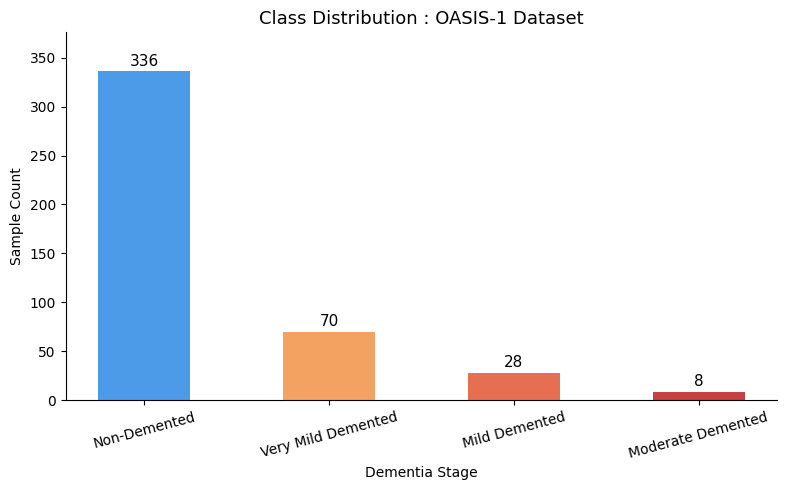

In [3]:
# Checking dementia label distribution

counts = df['dementia_stage_label'].value_counts().reindex(LABEL_ORDER)

fig, ax = plt.subplots(figsize=(8, 5))
bars = ax.bar(LABEL_ORDER, counts.values,
              color=['#4C9BE8', '#F4A261', '#E76F51', '#C94040'], width=0.5)

for bar, val in zip(bars, counts.values):
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 3,
            str(val), ha='center', va='bottom', fontsize=11)

ax.set_title('Class Distribution : OASIS-1 Dataset', fontsize=13)
ax.set_xlabel('Dementia Stage')
ax.set_ylabel('Sample Count')
ax.set_ylim(0, counts.max() + 40)
ax.tick_params(axis='x', labelrotation=15)
sns.despine()
plt.tight_layout()
plt.savefig(os.path.join(PLOTS_DIR, 'class_distribution.png'), dpi=150)
plt.show()

In [4]:
# Saving processed metadata

out_path = os.path.join(PROCESSED_DIR, 'metadata_processed.csv')
df.to_csv(out_path, index=False)
print(f'Saved {len(df)} rows → {out_path}')

Saved 442 rows → d:\Multi-Stage Alzheimers Classification Model\data\processed\metadata_processed.csv
